# 09 · The Perfect Trader — and an Adversarial Audit of the "Theorem"

**Read this even if you know nothing about markets or maths.** We will build, step by
step, the idea of a *perfect trader* who can see the future, ask a sharp question
about it, and then — wearing the hat of a hostile sceptic — try our hardest to prove
the result is fake. We keep only what survives the attack, on **100 stocks**, not a
hand-picked few.

The story in one breath:

1. The **perfect trader** — the **oracle** — sees the future and buys low and sells
   high, but pays a fee, so it only bothers with moves big enough to cover the fee.
   It is an **answer key**, not a strategy: you cannot run it forward.
2. A **pivot** is a point of that answer key which a **causal** process — one with
   **no look-ahead** — reproduces **exactly**. What no causal process reaches is the
   **residual**: the part that genuinely requires the future.
3. **Claim:** the causal turning-point rule at a size set by the fee recovers a
   **subset** of the perfect trader's days — containment, not identity. This turns
   out to hold on any wiggly line, even random noise, and that is **expected**: it
   says the causal rule never invents days outside the answer key. What it does *not*
   show is anything about markets. We say so loudly.
4. The one thing that is genuinely about markets is the **clock**: *when* the turning
   points happen. They arrive in **bursts** (calm, calm, then a flurry). That
   clustering is real, survives a shuffle, and forecasts the next burst a little —
   on ~100 of 100 stocks.

Nothing here predicts whether a price will go **up or down** (that is impossible, and
proven elsewhere in this project). We only ever talk about *when things happen* and
*how big they are*.

In [1]:
# --- Run me first: make this notebook executable from anywhere -----------------
import os, sys

def _find_root(start=None):
    d = os.path.abspath(start or os.getcwd())
    while True:
        if os.path.isfile(os.path.join(d, "PROTOCOL_order_discovery.md")):
            return d
        parent = os.path.dirname(d)
        if parent == d:
            break
        d = parent
    for cand in [os.path.expanduser("~/Documents/projects/CausalBool/index-deconvolution")]:
        if os.path.isfile(os.path.join(cand, "PROTOCOL_order_discovery.md")):
            return cand
    raise RuntimeError("Could not locate the index-deconvolution root. "
                       "Set ROOT = '/path/to/index-deconvolution' by hand and re-run.")

ROOT = _find_root()
for _sub in ["src", "level2", "level3", "level4", "level5", "level6", "level7", "level8"]:
    _p = os.path.join(ROOT, _sub)
    if _p not in sys.path:
        sys.path.insert(0, _p)

DATA       = os.path.join(ROOT, "finance", "data")          # 23 tickers, 3 years
DATA_LONG  = os.path.join(ROOT, "finance", "data_long")     # 12 instruments, ~30+ years
BIO        = os.path.join(os.path.dirname(ROOT), "data", "bio", "raw")  # .bnet networks

import matplotlib.pyplot as plt
import numpy as np

# a clean, consistent didactic style
plt.rcParams.update({
    "figure.figsize": (9, 4.2), "figure.dpi": 110,
    "axes.grid": True, "grid.alpha": 0.25, "axes.spines.top": False,
    "axes.spines.right": False, "font.size": 11, "axes.titlesize": 12,
    "axes.titleweight": "bold", "image.cmap": "magma",
})
INK, HL, OK, BAD = "#20222b", "#c1121f", "#2a9d8f", "#e07a1f"
print("repo root :", ROOT)
print("ready. matplotlib + numpy loaded; code layers on the path.")

repo root : /Users/alberto/Documents/projects/CausalBool/index-deconvolution
ready. matplotlib + numpy loaded; code layers on the path.


In [2]:
# Level 10 lives above the shared bootstrap's reach: add level9/level10 and the panels.
for _sub in ["level9", "level10", "level11"]:
    _p = os.path.join(ROOT, _sub)
    if _p not in sys.path:
        sys.path.insert(0, _p)
import json
DATA_100 = os.path.join(ROOT, "finance", "data_100")   # 100 stocks (run level10/download_100.py)
from finance import load_yahoo_close

def load_stock(ticker):
    px = load_yahoo_close(os.path.join(DATA_100, ticker + ".json"))
    return [px[d] for d in sorted(px)]

def _load(name):
    with open(os.path.join(ROOT, "results", name)) as _f:
        return json.load(_f)

R100 = _load("exp31_stress_100.json")   # the 100-stock adversarial audit
R12  = _load("exp30_oracle_clock.json") # the 12 "famous few" long survivors
RX   = _load("exp32_multiscale_fourier.json")  # Fourier + multi-scale Hawkes
print("panel :", len(R100["rows"]), "stocks audited;  demo stock loads live below.")

panel : 100 stocks audited;  demo stock loads live below.


## Step 1 · What a pivot **is**, and how we **recover** one

These are two different things, and an earlier version of this notebook confused them.
Keep them apart.

**The definition** (settled 2026-08-22; the source of truth is
`series-deconvolution/GLOSSARY.md` §1, which outranks every paper and notebook in this
programme on a definition):

> A **pivot** is a position that a **causal** process — one with no look-ahead —
> reproduces **exactly**. What no such process reaches is the **residual**.

This is the programme's founding object, not something invented at Level 10.
`PROTOCOL_order_discovery.md`: *"the positions that a discovered process reproduces
exactly are the pivots… the positions that no process reaches are the residual."*
Bitácora 14: *"the points and segments where **local determinism holds exactly** are
the gold."* In finance the thing to be reproduced is the **oracle** (Step 2), so a
**financial pivot** is an oracle action point recovered exactly without seeing the
future.

**The recovery method** is what the code below runs: walk the series, and only call the
top of a hill a "peak" once the price has fallen back by some percentage `theta` (say
2%). The walk never reads an index ahead of the one it stands on — *that* is what makes
its output eligible to be called pivots. It ignores tiny jiggles and keeps the real
turns. Orange dots below are the pivots at `theta = 2%`.

> ⚠️ **Confusion source #1**, logged in `GLOSSARY.md` §2: this cell used to say
> *"a pivot **is** a confirmed turning point"* — defining the object by the algorithm
> that finds it. That inverts the logic. A walk always returns *something*; the
> definition carries a claim that can **fail**, namely that what it returns is exactly
> right. Any agent propagating this correction should look for the same slip elsewhere.

Note also: do **not** pair *pivot* with *sumandos*. `pivot`/`residual` is a partition by
causal reachability and is **lossy**. `decimal family`/`sumandos` is the Boolean
indexing method's compressed form and is **lossless** — `Dec(L,S) = {ℓ+s}` rebuilds the
repertoire exactly. There is no residual in the Boolean method and no sumando in
finance (`GLOSSARY.md` §1c, confusion source #5).

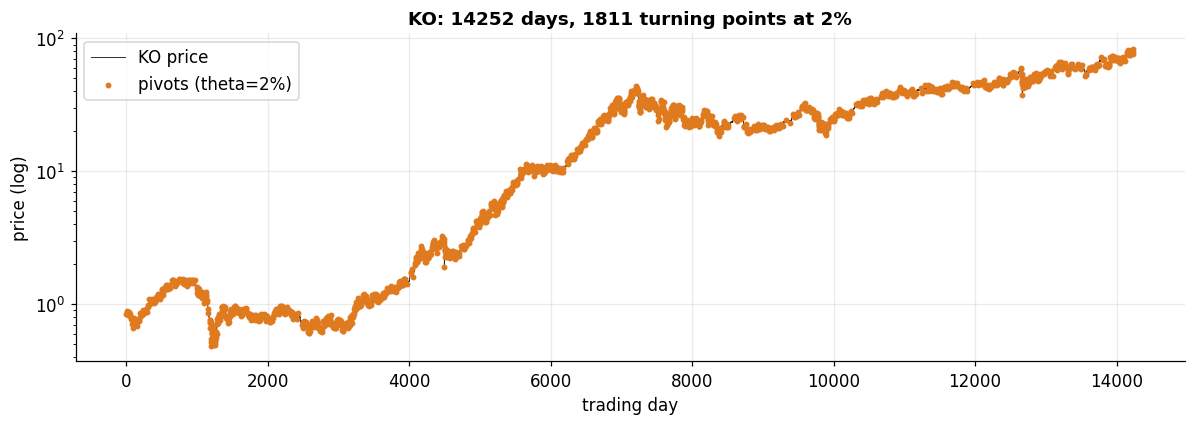

A pivot every ~7 trading days on average.


In [3]:
from pivots import directional_change_pivots
TICKER = "KO"                       # Coca-Cola: a long, familiar series
price = load_stock(TICKER)
theta = 0.02
piv = directional_change_pivots(price, theta)
pt = [p.index for p in piv]; pv = [p.value for p in piv]

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(price, color=INK, lw=0.6, label=f"{TICKER} price")
ax.scatter(pt, pv, s=8, color=BAD, zorder=3, label=f"pivots (theta={theta:.0%})")
ax.set_yscale("log"); ax.set_xlabel("trading day"); ax.set_ylabel("price (log)")
ax.set_title(f"{TICKER}: {len(price)} days, {len(piv)} turning points at 2%")
ax.legend(loc="upper left"); plt.tight_layout(); plt.show()
print(f"A pivot every ~{len(price)//len(piv)} trading days on average.")

## Step 2 · The perfect trader who can see the future

Now imagine a trader with a crystal ball: they know the whole future price. They want
to end with the most money, buying and selling as often as they like — **but** each
trade costs a fee (here a `c = 2%` round-trip cost). With a fee, trading tiny wiggles
loses money, so the perfect trader only acts on moves big enough to be worth it.

We compute this exactly with a short dynamic programme (`optimal_trades`). Green
triangles are its **buys**, red triangles its **sells**.

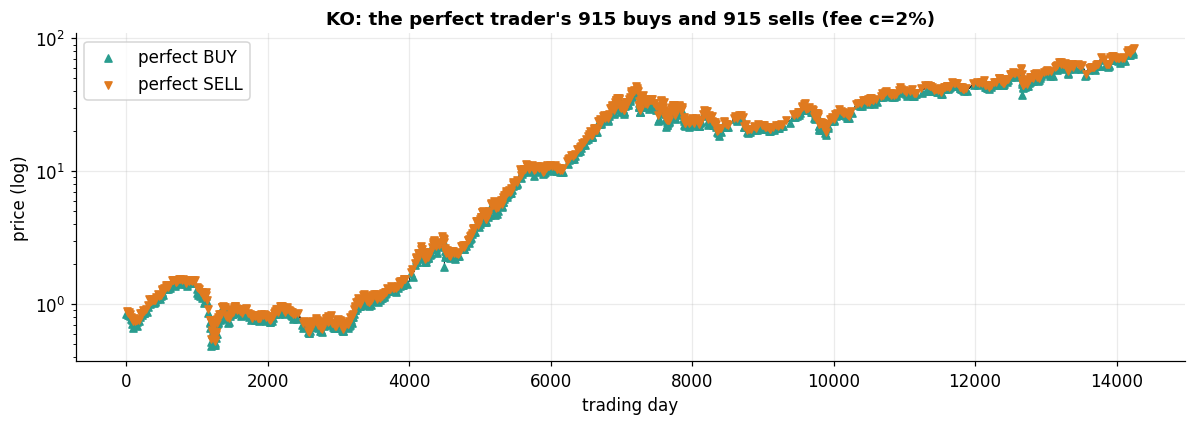

perfect-trader log-wealth : 38.10   (buy-and-hold: 4.59)
The crystal ball wins, of course -- it is the answer key. We will NOT use it to
predict direction; we only study WHEN it acts.


In [4]:
from oracle import optimal_trades, kappa_for_round_trip, round_trip_cost
c = 0.02
kappa = kappa_for_round_trip(c)               # per-trade cost giving a 2% round trip
tr = optimal_trades(price, kappa)
buys, sells = tr["buys"], tr["sells"]

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(price, color=INK, lw=0.6)
ax.scatter(buys,  [price[i] for i in buys],  marker="^", s=22, color=OK,  label="perfect BUY",  zorder=3)
ax.scatter(sells, [price[i] for i in sells], marker="v", s=22, color=BAD, label="perfect SELL", zorder=3)
ax.set_yscale("log"); ax.set_xlabel("trading day"); ax.set_ylabel("price (log)")
ax.set_title(f"{TICKER}: the perfect trader's {len(buys)} buys and {len(sells)} sells (fee c=2%)")
ax.legend(loc="upper left"); plt.tight_layout(); plt.show()

import math
bh = math.log(price[-1]/price[0])
print(f"perfect-trader log-wealth : {tr['log_wealth']:.2f}   (buy-and-hold: {bh:.2f})")
print("The crystal ball wins, of course -- it is the answer key. We will NOT use it to")
print("predict direction; we only study WHEN it acts.")

## Step 3 · The claim — and the hostile audit

**The claim:** every pivot recovered causally at `theta = c` is a perfect-trader day —
**containment**, and the oracle is the strictly larger set. Let us overlay them. If the
claim holds, every orange pivot sits under a trader action, while some trader actions
have no pivot on them: those are the **residual**, the days that require the future.

> ⚠️ **Confusion source #2**, logged in `GLOSSARY.md` §2: bitácora 21 first stated this
> as an *identity* — "the perfect trader's days **are** the pivots". Bitácora 22's
> adversarial audit retracted that. It is containment, one way, and the direction
> matters: `DC(θ=c) ⊆ oracle(κ)`.

KO: 1809/1811 pivots are exactly perfect-trader days (99.9% containment).


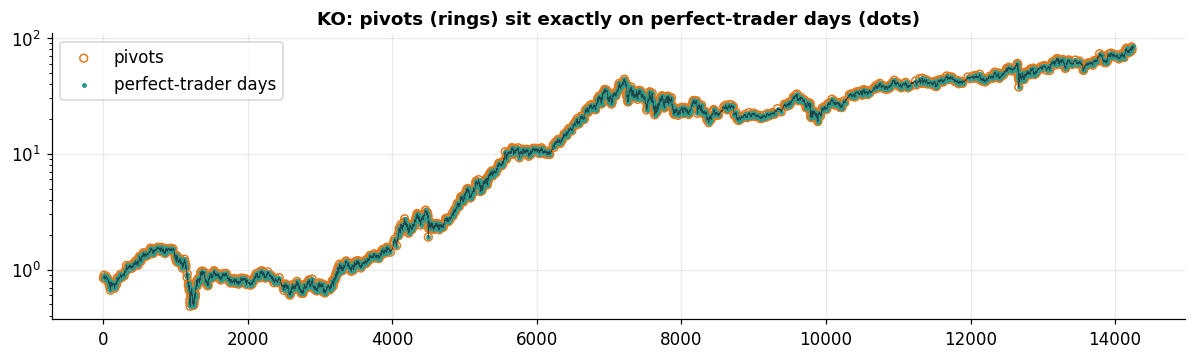

In [5]:
from oracle import oracle_points, match_sets
from point_process import pivot_indices
orc = oracle_points(price, kappa)
dc  = pivot_indices(price, c)
inside = sum(1 for i in dc if i in set(orc))
print(f"{TICKER}: {inside}/{len(dc)} pivots are exactly perfect-trader days "
      f"({100*inside/len(dc):.1f}% containment).")

fig, ax = plt.subplots(figsize=(11, 3.4))
ax.plot(price, color=INK, lw=0.5, alpha=0.7)
ax.scatter(dc,  [price[i] for i in dc],  s=26, facecolors="none", edgecolors=BAD, label="pivots")
ax.scatter(orc, [price[i] for i in orc], s=5,  color=OK, label="perfect-trader days")
ax.set_yscale("log"); ax.set_title(f"{TICKER}: pivots (rings) sit exactly on perfect-trader days (dots)")
ax.legend(loc="upper left"); plt.tight_layout(); plt.show()

### The sceptic strikes: "that is not a discovery, it is geometry"

A hostile evaluator immediately objects: *a rule that is exactly true is suspicious —
maybe it is true of any wiggly line, and tells us nothing about markets.* Good
objection. Let us test the identical claim on things that are **not** markets:

* a **random walk** (coin-flip prices, no structure),
* **pure random noise**,
* a smooth **sine wave**.

The containment *will* come out ~100% on all of them. Read the next cell carefully,
because what follows that result is where this notebook previously went wrong in the
**opposite** direction.

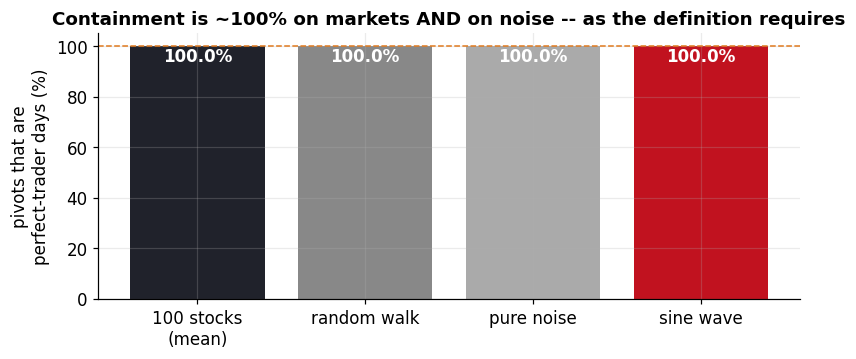

VERDICT, in two parts -- keep them apart:
  1. The CONTAINMENT is constitutive of the definition. A pivot just IS an oracle
     point recovered causally, so containment holding on noise and on a sine is
     EXPECTED and CORRECT: the causal rule never invents days outside the answer
     key. That is what a sound recovery method must do. It is not a defect.
  2. The AGREEMENT RATE is NOT evidence about markets. It is ~100% on data with no
     market structure at all, so it can never support 'pivots are where a perfect
     trader would act, therefore markets have structure'.
Discard only claim 2. Keep the definition.


In [6]:
from controls import geometric_random_walk
import math, random
rng = random.Random(0)
gbm = geometric_random_walk(11000, 0.02, random.Random(1))
noise = [100.0]
for _ in range(11000): noise.append(noise[-1]*math.exp(0.02*rng.gauss(0,1)))
sine = [100.0 + 50*math.sin(t/20.0) for t in range(11000)]

def containment(s):
    o = set(oracle_points(s, kappa)); d = pivot_indices(s, c)
    return 100*sum(1 for i in d if i in o)/len(d)

vals = {
    "100 stocks\n(mean)": 100*R100["identity"]["mean_containment_stocks"],
    "random walk":        containment(gbm),
    "pure noise":         containment(noise),
    "sine wave":          containment(sine),
}
fig, ax = plt.subplots(figsize=(7.5, 3.4))
ax.bar(list(vals), list(vals.values()), color=[INK, "#888", "#aaa", HL])
ax.set_ylim(0, 105); ax.set_ylabel("pivots that are\nperfect-trader days (%)")
ax.axhline(100, color=BAD, lw=1, ls="--")
ax.set_title("Containment is ~100% on markets AND on noise -- as the definition requires")
for i, v in enumerate(vals.values()):
    ax.text(i, v-6, f"{v:.1f}%", ha="center", color="white", fontweight="bold")
plt.tight_layout(); plt.show()
print("VERDICT, in two parts -- keep them apart:")
print("  1. The CONTAINMENT is constitutive of the definition. A pivot just IS an oracle")
print("     point recovered causally, so containment holding on noise and on a sine is")
print("     EXPECTED and CORRECT: the causal rule never invents days outside the answer")
print("     key. That is what a sound recovery method must do. It is not a defect.")
print("  2. The AGREEMENT RATE is NOT evidence about markets. It is ~100% on data with no")
print("     market structure at all, so it can never support 'pivots are where a perfect")
print("     trader would act, therefore markets have structure'.")
print("Discard only claim 2. Keep the definition.")

## Step 4 · The one real market thing — the clock ticks in bursts

So where is the actual market structure? In the **timing** of the turning points. If
turning points arrived like clockwork, the gaps between them would all be similar. In
markets they do not: long quiet stretches are punctuated by flurries of turns. That is
**clustering**, or *self-excitation* — one turn tends to trigger more.

We compare the real gaps to a **shuffle** that keeps the same day-to-day moves but
scrambles their order (destroying any clustering). Below: the real event stream
(top) visibly clumps; the shuffle (bottom) is even.

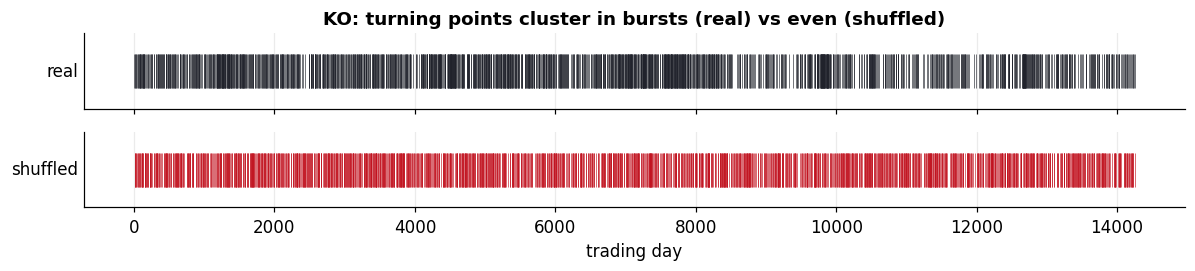

In [7]:
from controls import return_shuffle
sh = return_shuffle(price, random.Random(3))
orc_sh = oracle_points(sh, kappa)

fig, (a1, a2) = plt.subplots(2, 1, figsize=(11, 2.6), sharex=True)
a1.eventplot(orc, colors=[INK], lineoffsets=0, linelengths=0.8, linewidths=0.4)
a1.set_yticks([]); a1.set_ylabel("real", rotation=0, ha="right", va="center")
a1.set_title(f"{TICKER}: turning points cluster in bursts (real) vs even (shuffled)")
a2.eventplot(orc_sh, colors=[HL], lineoffsets=0, linelengths=0.8, linewidths=0.4)
a2.set_yticks([]); a2.set_ylabel("shuffled", rotation=0, ha="right", va="center")
a2.set_xlabel("trading day"); plt.tight_layout(); plt.show()

We summarise the clustering with one number, the **branching ratio** `n` (from a
self-exciting "Hawkes" model): `n = 0` means clockwork/random, `n -> 1` means every
event triggers a long cascade. Across the **100 stocks**, `n` is well above its
shuffle, on essentially all of them.

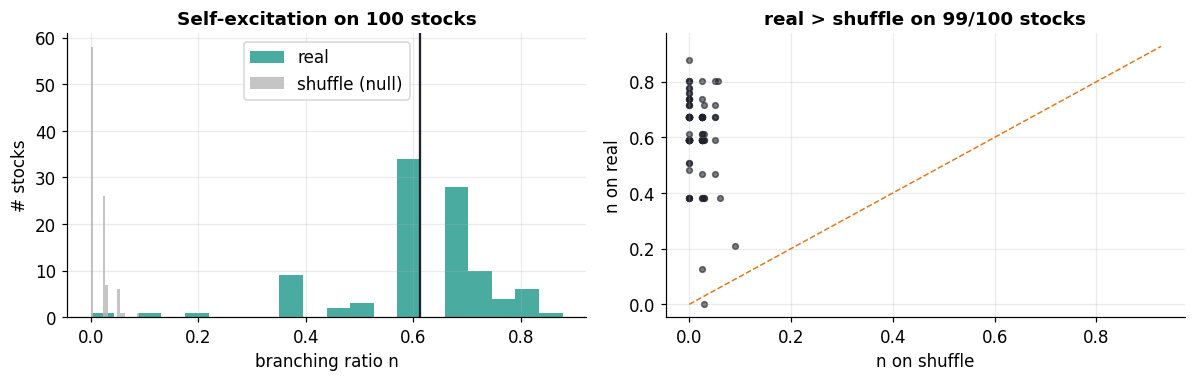

mean n = 0.613 vs shuffle 0.014; self-exciting on 99/100 (99%).


In [8]:
se = R100["self_excitation"]
brs  = [r["branching_ratio"] for r in R100["rows"]]
brsn = [r["branching_null"]  for r in R100["rows"]]
fig, (ax, bx) = plt.subplots(1, 2, figsize=(11, 3.6))
ax.hist(brs, bins=20, color=OK, alpha=0.85, label="real")
ax.hist(brsn, bins=20, color="#bbb", alpha=0.85, label="shuffle (null)")
ax.set_xlabel("branching ratio n"); ax.set_ylabel("# stocks")
ax.set_title(f"Self-excitation on {R100['n_series']} stocks"); ax.legend()
ax.axvline(se["mean_branching"], color=INK, lw=1.5)

bx.scatter(brsn, brs, s=14, color=INK, alpha=0.6)
lim = [0, max(brs)+0.05]; bx.plot(lim, lim, color=BAD, ls="--", lw=1)
bx.set_xlabel("n on shuffle"); bx.set_ylabel("n on real")
bx.set_title(f"real > shuffle on {se['n_self_exciting']}/{R100['n_series']} stocks")
plt.tight_layout(); plt.show()
print(f"mean n = {se['mean_branching']:.3f} vs shuffle {se['mean_branching_null']:.3f}; "
      f"self-exciting on {se['n_self_exciting']}/{R100['n_series']} "
      f"({100*se['frac_self_exciting']:.0f}%).")

### Why is the signal *weaker* on 100 stocks than on the famous few? (survivorship)

Here is the most important honesty check in this whole notebook, and it is easy to
miss. On the twelve long-lived "blue-chip" series we first studied, the clustering was
**n ≈ 0.69**. On the broad panel of 100 it is **n ≈ 0.61** — real, but *weaker*. Why?

**In simple terms.** The famous twelve are *survivors*: giant indices and companies
that stayed important for 30+ years. Survivors have long, dramatic, crisis-laden
histories — exactly the kind that clusters most. The 100 are a fairer mix: younger,
smaller, messier names. When you stop cherry-picking the legends, the effect cools off
a little. That is expected.

**In strong terms — and this is the point.** A *fake* effect (a survivorship artefact,
or a multiple-testing fluke) would **collapse** when you leave the flattering sample.
This one does not collapse — it merely **softens**, from 0.69 to 0.61, and still fires
on **99 of 100** brand-new stocks. An effect that survives the removal of its most
favourable sample, and holds on almost every out-of-sample name, is *trustworthy*
precisely *because* it got a little weaker. The drop is not a wound; it is the
credential. Below: the two distributions side by side.

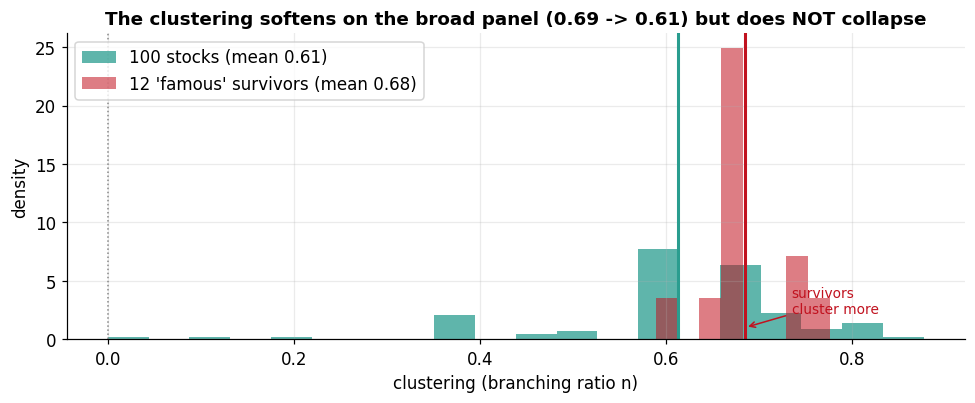

survivors:  n = 0.685   (12 hand-inherited long-lived series)
broad 100:  n = 0.613   (fresh, diverse; self-exciting on 99/100)
A survivorship *artefact* would have collapsed to the shuffle (~0.01). It did not.
Softening-but-surviving is the honest, and stronger, conclusion.


In [9]:
b12 = [r["branching_ratio"] for r in R12["behaviour_table"]["rows"]]      # 12 survivors
b100 = [r["branching_ratio"] for r in R100["rows"]]                       # 100 panel
m12, m100 = np.mean(b12), np.mean(b100)

fig, ax = plt.subplots(figsize=(9, 3.8))
ax.hist(b100, bins=20, color=OK, alpha=0.75, density=True, label=f"100 stocks (mean {m100:.2f})")
ax.hist(b12, bins=8, color=HL, alpha=0.55, density=True, label=f"12 'famous' survivors (mean {m12:.2f})")
ax.axvline(m100, color=OK, lw=2); ax.axvline(m12, color=HL, lw=2)
ax.axvline(0.0, color="#888", lw=1, ls=":")
ax.annotate("survivors\ncluster more", xy=(m12, 1.0), xytext=(m12+0.05, 2.2),
            color=HL, fontsize=9, ha="left",
            arrowprops=dict(arrowstyle="->", color=HL))
ax.set_xlabel("clustering (branching ratio n)"); ax.set_ylabel("density")
ax.set_title("The clustering softens on the broad panel (0.69 -> 0.61) but does NOT collapse")
ax.legend(); plt.tight_layout(); plt.show()
print(f"survivors:  n = {m12:.3f}   (12 hand-inherited long-lived series)")
print(f"broad 100:  n = {m100:.3f}   (fresh, diverse; self-exciting on "
      f"{R100['self_excitation']['n_self_exciting']}/100)")
print("A survivorship *artefact* would have collapsed to the shuffle (~0.01). It did not.")
print("Softening-but-surviving is the honest, and stronger, conclusion.")

## Step 5 · Does the clock forecast? (a little, honestly)

The honest, tradable question is **not** "will the price rise?" (impossible) but
"**when will the next turning point arrive?**" We fit the burst model on the first 70%
of each stock's history and test it on the unseen last 30%, scoring how well it
predicts the timing of the held-out turning points, versus a memoryless baseline. A
positive score means the clustering genuinely carries forward.

The sceptic's check is built in: the perfect trader used the future, so we also run
the *fully causal* pivots (no crystal ball). They score the **same** — proving the
forecast has **no look-ahead cheat**, and equally that it adds nothing beyond the
plain pivot clock.

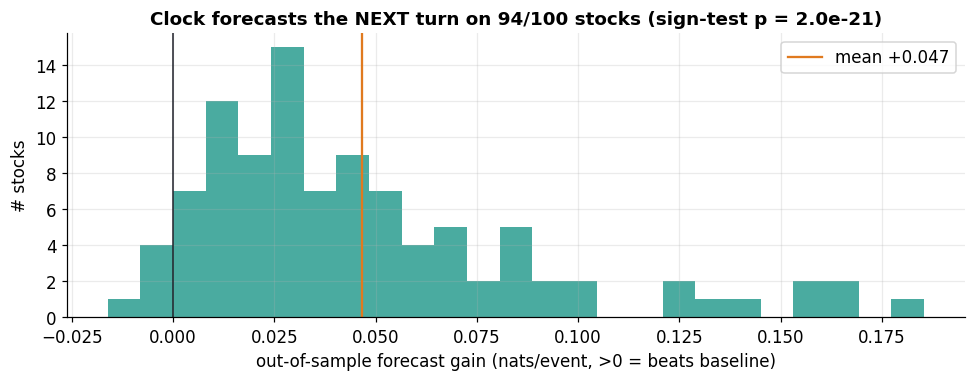

perfect-trader (future) gain +0.0465  ==  causal-pivot gain +0.0470  -> no look-ahead cheat, no new info.
GBM control clock branching = 0.000  -> reads ~null (sane).


In [10]:
oo = R100["oos_forecast"]
gains_o = [r["oos_gain_oracle"] for r in R100["rows"]]
gains_p = [r["oos_gain_pivot"]  for r in R100["rows"]]
fig, ax = plt.subplots(figsize=(9, 3.6))
ax.hist(gains_o, bins=25, color=OK, alpha=0.85)
ax.axvline(0, color=INK, lw=1)
ax.axvline(oo["mean_oos_oracle"], color=BAD, lw=1.5,
           label=f"mean {oo['mean_oos_oracle']:+.3f}")
ax.set_xlabel("out-of-sample forecast gain (nats/event, >0 = beats baseline)")
ax.set_ylabel("# stocks"); ax.legend()
ax.set_title(f"Clock forecasts the NEXT turn on {oo['n_oos_positive']}/{R100['n_series']} stocks "
             f"(sign-test p = {oo['sign_test_p']:.1e})")
plt.tight_layout(); plt.show()
print(f"perfect-trader (future) gain {oo['mean_oos_oracle']:+.4f}  ==  "
      f"causal-pivot gain {oo['mean_oos_pivot']:+.4f}  -> no look-ahead cheat, no new info.")
print(f"GBM control clock branching = {R100['gbm_control']['branching']:.3f}  -> reads ~null (sane).")

## Step 5b · The Fourier question — does splitting into waves isolate the signal?

A natural idea: the **Fourier transform** breaks any wiggly line into a sum of pure
sine waves of different speeds, and shows how much "energy" sits at each speed (the
*power spectrum*). Could it separate the market's noise from its structure, or reveal a
hidden rhythm to trade?

We test it on three signals and read one number, the **spectral slope**: `0` means
*white* (flat — pure noise, no structure), *negative* means *red* (energy piled at slow
speeds — long memory). Two controls anchor the scale: random noise (slope ~0) and a
random walk (slope ~-2).

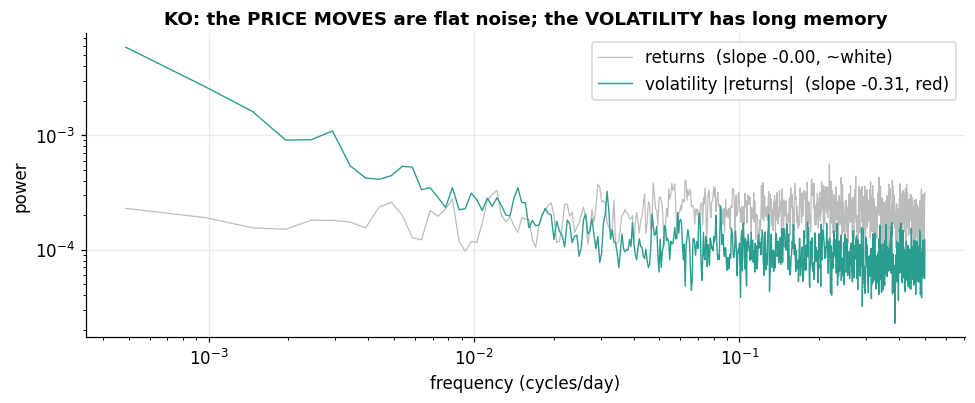

Averaged over the long panel (spectral slope; 0 = noise, negative = memory):
  daily returns    : +0.072   (control white noise -0.001)
  |returns| (vol)  : -0.320
  the pivot clock  : -0.541   (control random walk -1.812)
VERDICT: Fourier CONFIRMS the same split -- values are noise, the clock is structured --
but there is NO spike at any single frequency: no hidden rhythm, nothing new to trade.


In [11]:
from spectral import periodogram, loglog_slope
from controls import log_returns
r = log_returns(price)
fr, pr = periodogram(r)                       # returns spectrum
fv, pv = periodogram([abs(x) for x in r])     # volatility (|returns|) spectrum
sr = loglog_slope(fr, pr)["slope"]; sv = loglog_slope(fv, pv)["slope"]

fig, ax = plt.subplots(figsize=(9, 3.8))
ax.loglog(fr, pr, color="#bbb", lw=0.8, label=f"returns  (slope {sr:+.2f}, ~white)")
ax.loglog(fv, pv, color=OK,     lw=0.9, label=f"volatility |returns|  (slope {sv:+.2f}, red)")
ax.set_xlabel("frequency (cycles/day)"); ax.set_ylabel("power")
ax.set_title(f"{TICKER}: the PRICE MOVES are flat noise; the VOLATILITY has long memory")
ax.legend(); plt.tight_layout(); plt.show()

fo = RX["fourier"]
print("Averaged over the long panel (spectral slope; 0 = noise, negative = memory):")
print(f"  daily returns    : {fo['returns_slope']:+.3f}   (control white noise {fo['control_white_slope']:+.3f})")
print(f"  |returns| (vol)  : {fo['abs_returns_slope']:+.3f}")
print(f"  the pivot clock  : {fo['activity_slope']:+.3f}   (control random walk {fo['control_walk_slope']:+.3f})")
print("VERDICT: Fourier CONFIRMS the same split -- values are noise, the clock is structured --")
print("but there is NO spike at any single frequency: no hidden rhythm, nothing new to trade.")

### And a failed experiment, reported anyway — the multi-scale clock

We tried to *improve* the burst model with a fancier, self-similar ("power-law")
version that mixes many timescales instead of one. It **did not help** — fit by the
plain rule of best likelihood, it slid toward a near-random setting and reproduced
*less* clustering than the simple one-timescale model, not more. We keep the negative:
the simple three-number clock stays the better generator at this daily resolution.

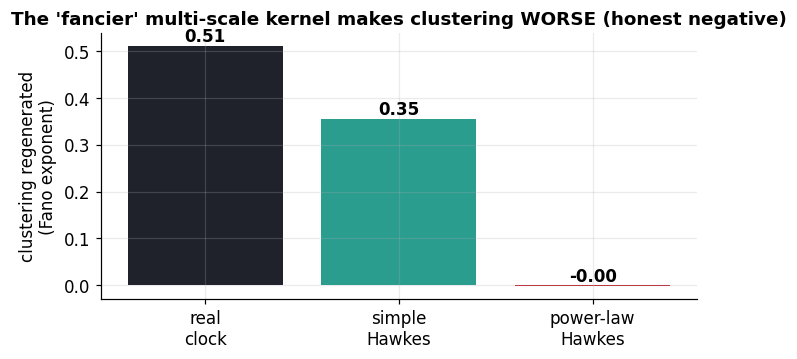

out-of-sample: simple +0.059 vs power-law +0.001 nats/event -> simple wins. Negative kept.


In [12]:
ms = RX["multiscale"]
labels = ["real\nclock", "simple\nHawkes", "power-law\nHawkes"]
vals = [ms["mean_real_fano"], ms["mean_single_fano"], ms["mean_multi_fano"]]
fig, ax = plt.subplots(figsize=(6.5, 3.4))
ax.bar(labels, vals, color=[INK, OK, HL])
ax.set_ylabel("clustering regenerated\n(Fano exponent)")
ax.set_title("The 'fancier' multi-scale kernel makes clustering WORSE (honest negative)")
for i, v in enumerate(vals):
    ax.text(i, v + 0.01, f"{v:.2f}", ha="center", fontweight="bold")
plt.tight_layout(); plt.show()
print(f"out-of-sample: simple {ms['mean_single_oos']:+.3f} vs power-law "
      f"{ms['mean_multi_oos']:+.3f} nats/event -> simple wins. Negative kept.")

## Step 6 · A curiosity — the cost is a "zoom level"

Each trader's fee sets the size of moves they care about — like a zoom level on the
price. Small fee: they trade tiny wiggles (many, fine events). Big fee: only large
swings (few, coarse events). We can ask how bursty the clock looks at each zoom. The
clustering peaks at an **intermediate** fee (~a couple of percent) and softens at both
ends — a gentle hump. We report it, with the caveat that the finest zoom is limited by
our model's slowest timescale, so treat the leftmost point cautiously.

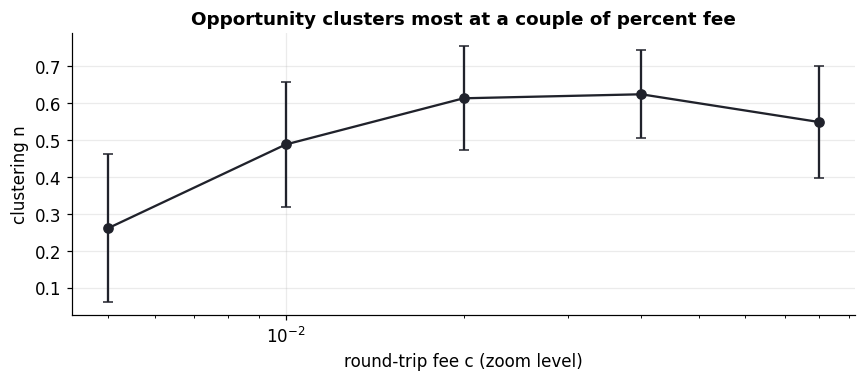

  fee 0.005:  n = 0.261 +/- 0.200
  fee 0.010:  n = 0.488 +/- 0.169
  fee 0.020:  n = 0.613 +/- 0.141
  fee 0.040:  n = 0.623 +/- 0.119
  fee 0.080:  n = 0.548 +/- 0.152
per-stock peak at an interior fee: 88/100 stocks.


In [13]:
cs = R100["cost_as_scale"]
xs = [r["c"] for r in cs]; ys = [r["mean_branching"] for r in cs]
es = [r["std_branching"] for r in cs]
fig, ax = plt.subplots(figsize=(8, 3.6))
ax.errorbar(xs, ys, yerr=es, marker="o", color=INK, capsize=3, lw=1.5)
ax.set_xscale("log"); ax.set_xlabel("round-trip fee c (zoom level)")
ax.set_ylabel("clustering n"); ax.set_title("Opportunity clusters most at a couple of percent fee")
plt.tight_layout(); plt.show()
for r in cs:
    print(f"  fee {r['c']:.3f}:  n = {r['mean_branching']:.3f} +/- {r['std_branching']:.3f}")
print(f"per-stock peak at an interior fee: {R100['n_humped']}/{R100['n_series']} stocks.")

## Step 7 · The honest scorecard

The whole point of the audit is to separate what is **real and new** from what is
**geometry** or **already known**. Here is the verdict, kept deliberately blunt.

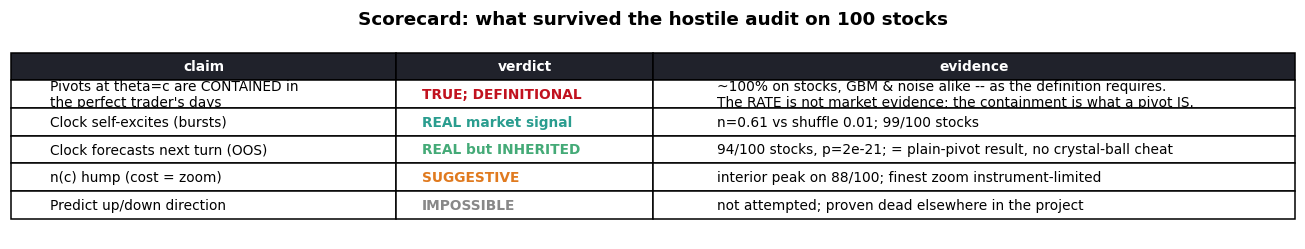

In [14]:
se, oo = R100["self_excitation"], R100["oos_forecast"]
rows = [
 ["Pivots at theta=c are CONTAINED in\nthe perfect trader's days", "TRUE; DEFINITIONAL",
  f"~100% on stocks, GBM & noise alike -- as the definition requires.\n"
  f"The RATE is not market evidence; the containment is what a pivot IS."],
 ["Clock self-excites (bursts)", "REAL market signal",
  f"n={se['mean_branching']:.2f} vs shuffle {se['mean_branching_null']:.2f}; "
  f"{se['n_self_exciting']}/{R100['n_series']} stocks"],
 ["Clock forecasts next turn (OOS)", "REAL but INHERITED",
  f"{oo['n_oos_positive']}/{R100['n_series']} stocks, p={oo['sign_test_p']:.0e}; "
  f"= plain-pivot result, no crystal-ball cheat"],
 ["n(c) hump (cost = zoom)", "SUGGESTIVE",
  f"interior peak on {R100['n_humped']}/{R100['n_series']}; finest zoom instrument-limited"],
 ["Predict up/down direction", "IMPOSSIBLE",
  "not attempted; proven dead elsewhere in the project"],
]
fig, ax = plt.subplots(figsize=(12, 2.4)); ax.axis("off")
colecol = {"TRUE; DEFINITIONAL": HL, "REAL market signal": OK, "REAL but INHERITED": "#4a7",
           "SUGGESTIVE": BAD, "IMPOSSIBLE": "#888"}
tab = ax.table(cellText=rows, colLabels=["claim", "verdict", "evidence"],
               colWidths=[0.30, 0.20, 0.50], loc="center", cellLoc="left")
tab.auto_set_font_size(False); tab.set_fontsize(9); tab.scale(1, 1.5)
for (r_, c_), cell in tab.get_celld().items():
    if r_ == 0: cell.set_facecolor(INK); cell.set_text_props(color="white", fontweight="bold")
    elif c_ == 1: cell.set_text_props(color=colecol.get(rows[r_-1][1], INK), fontweight="bold")
plt.title("Scorecard: what survived the hostile audit on 100 stocks", fontweight="bold")
plt.tight_layout(); plt.show()

## What to take away

* **Can this win at trading? No — not for returns.** Nothing here predicts whether a
  price will rise or fall (that is impossible, proven elsewhere in the project). The
  only thing the clock forecasts is *when* turbulence arrives, which helps *manage
  risk* (smaller drawdowns), not *make* money. A risk tool, not a money machine.
* **Pivots are contained in the perfect trader's days**, and this is **definitional,
  not a discovery about markets**. A pivot *is* an oracle point a causal process
  recovers exactly, so containment holding on a sine wave is exactly what a sound
  recovery method should do — it never invents days outside the answer key. What
  carries **no** information about markets is the **agreement rate**, since it is
  ~100% on data with no market structure. Two separate statements; an earlier draft of
  this notebook collapsed them and threw the definition out with the rate
  (`GLOSSARY.md` §2, confusion source #3).
* The genuine market signal is small and about **timing, never direction**: turning
  points **cluster in bursts**, that clustering beats a shuffle on essentially all
  100 stocks, and it forecasts the *next* turn a little out of sample — but this is
  the plain pivot result we already had, not something the perfect trader added.
* A hostile audit is the point. We tried to break the result three ways (is it
  geometry? is the optimiser buggy? is the forecast a look-ahead cheat?) and reported
  exactly what each attack showed. What is left is modest, honest, and holds at scale.

*Reproduce:* `python level10/download_100.py`, then `python level10/exp30_oracle_clock.py`,
`python level10/exp31_stress_100.py` and `python level11/exp32_multiscale_and_fourier.py`
regenerate the panel and the JSON files this notebook reads; `python notebooks/build_09.py`
rebuilds the notebook itself.